In [18]:
from preprocessing.file_conversion import file_conversion
import numpy as np
from features import feature_extraction

#path = "/Users/reymendoza/Desktop/sleep_files"
#X, y, groups = file_conversion(path)

#np.savez_compressed("sleep_dataset.npz", X=X, y=y, groups=groups)

data = np.load("/Users/reymendoza/Developer/Sleep-Stage-Classification/preprocessing/sleep_dataset.npz", allow_pickle=True)
X = data["X"]
y = data["y"]
groups = data["groups"]
feature_df = feature_extraction(X)
feature_df['label'] = y
feature_df['label'] = feature_df['label'].replace({1: 'Awake', 2: 'REM', 3: 'N1', 4: 'N2', 5: 'N3'})
feature_df['group'] = groups

In [25]:
feature_df

,delta_abs_bandpower,theta_abs_bandpower,alpha_abs_bandpower,beta_abs_bandpower,gamma_abs_bandpower,delta_rel_bandpower,theta_rel_bandpower,alpha_rel_bandpower,beta_rel_bandpower,gamma_rel_bandpower,...,delta_alpha_ratio,theta_alpha_ratio,delta_beta_ratio,alpha_beta_ratio,hjorth_activity,hjorth_mobility,hjorth_complexity,spectral_entropy,label,group
0,-9.340358,-9.910352,-10.127414,-10.097334,-10.590217,0.602932,0.161317,0.097342,0.104418,0.032668,...,0.786103,0.213514,0.756023,-0.035943,1.268570e-09,0.213001,3.973660,6.677247,Awake,sub-001
1,-9.692165,-10.223911,-10.348477,-10.381935,-10.891655,0.564634,0.163995,0.122405,0.113122,0.033051,...,0.654169,0.117231,0.687627,0.023660,4.379164e-09,0.167247,5.872854,6.135448,Awake,sub-001
2,-9.632274,-9.985766,-10.359309,-10.192977,-10.738928,0.506301,0.223131,0.093152,0.137640,0.037596,...,0.725169,0.369319,0.558837,-0.176380,1.334319e-09,0.217025,4.118894,7.015822,Awake,sub-001
3,-9.776617,-10.091223,-10.311116,-10.243820,-10.700903,0.449203,0.216297,0.129290,0.151413,0.051095,...,0.531895,0.214501,0.464599,-0.076278,1.336577e-09,0.219342,3.961222,6.082853,Awake,sub-001
4,-8.951274,-7.830402,-8.681631,-8.971276,-9.658440,0.058029,0.767145,0.108011,0.055415,0.011347,...,-0.270031,0.851199,0.019614,0.289436,1.239783e-07,0.189165,4.968850,6.201722,Awake,sub-001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Awake,sub-008
7050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Awake,sub-008
7051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Awake,sub-008
7052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N2,sub-008


##### sub-008 appears to have all epochs with NaNs

In [19]:
feature_df.groupby("group").apply(lambda x: x.isna().any(axis=1).sum())

group
sub-001       0
sub-003       0
sub-004       0
sub-005       0
sub-006       0
sub-007       0
sub-008    1013
dtype: int64

In [20]:
feature_df['group'].value_counts()

group
sub-003    1068
sub-007    1035
sub-005    1028
sub-008    1013
sub-004    1006
sub-006     962
sub-001     942
Name: count, dtype: int64

#### __Label Distributions__
##### N2 sleep makes the majority of the sleep epochs, followed by REM, Awake, N3 (deep) sleep, and N1 sleep (the lowest proportion)

In [21]:
print(feature_df['label'].value_counts())
print(feature_df['label'].value_counts(normalize=True))

label
N2       3041
REM      1254
Awake    1111
N3        976
N1        672
Name: count, dtype: int64
label
N2       0.431103
REM      0.177771
Awake    0.157499
N3       0.138361
N1       0.095265
Name: proportion, dtype: float64


#### __Label Distributions__
##### N2 sleep makes the majority of the sleep epochs, followed by REM, Awake, N3 (deep) sleep, and N1 sleep (the lowest proportion)

<Axes: xlabel='label', ylabel='delta_abs_bandpower'>

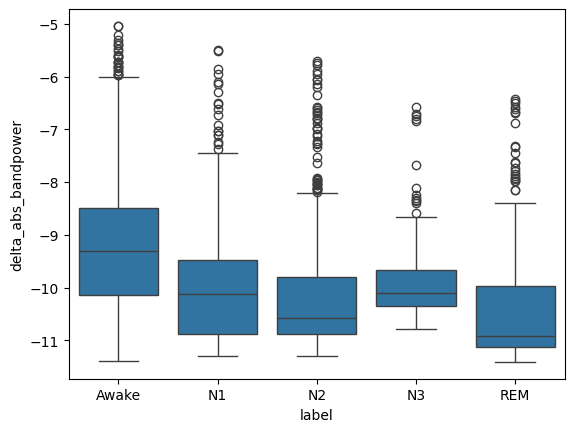

In [22]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='delta_abs_bandpower')

<Axes: xlabel='label', ylabel='theta_abs_bandpower'>

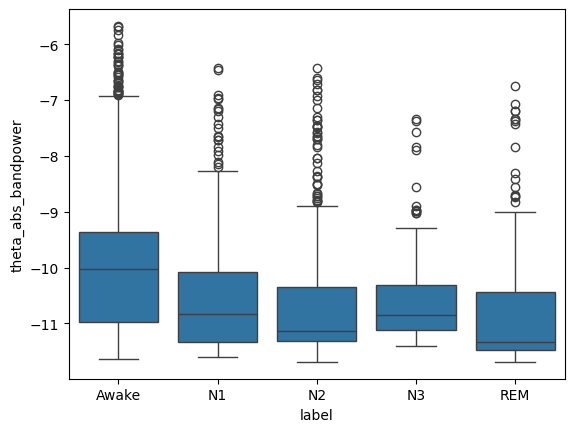

In [23]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='theta_abs_bandpower')

<Axes: xlabel='label', ylabel='alpha_abs_bandpower'>

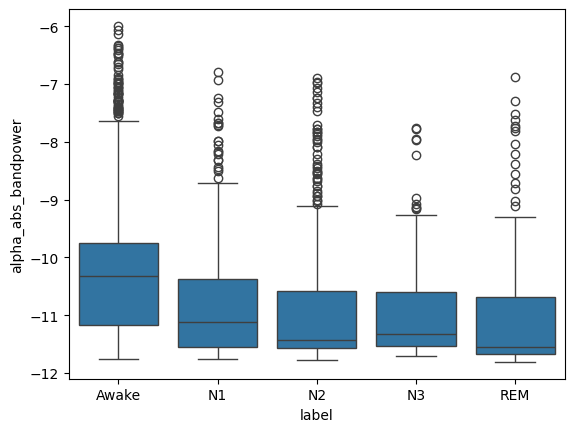

In [24]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='alpha_abs_bandpower')

<Axes: xlabel='label', ylabel='delta_rel_bandpower'>

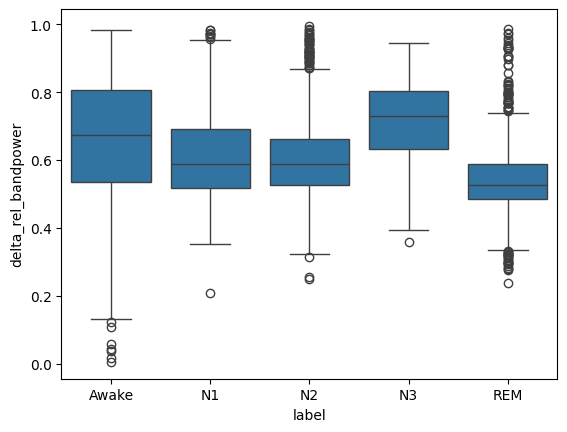

In [26]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='delta_rel_bandpower')

<Axes: xlabel='label', ylabel='theta_rel_bandpower'>

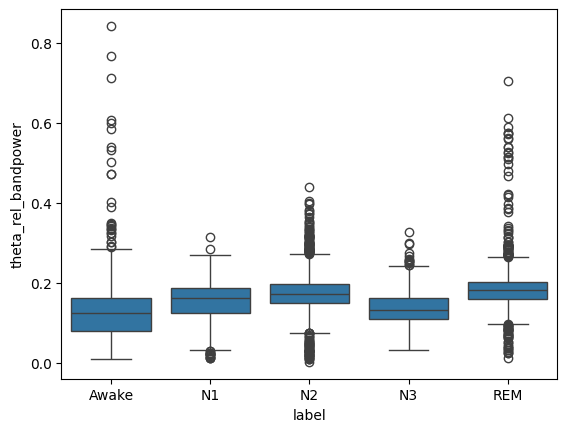

In [28]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='theta_rel_bandpower')

<Axes: xlabel='label', ylabel='alpha_rel_bandpower'>

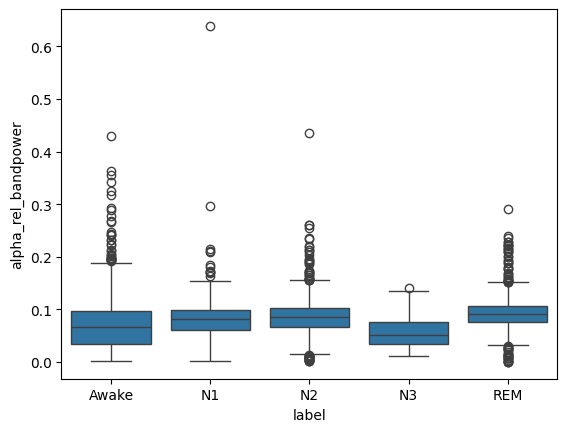

In [29]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='alpha_rel_bandpower')

<Axes: xlabel='label', ylabel='delta_theta_ratio'>

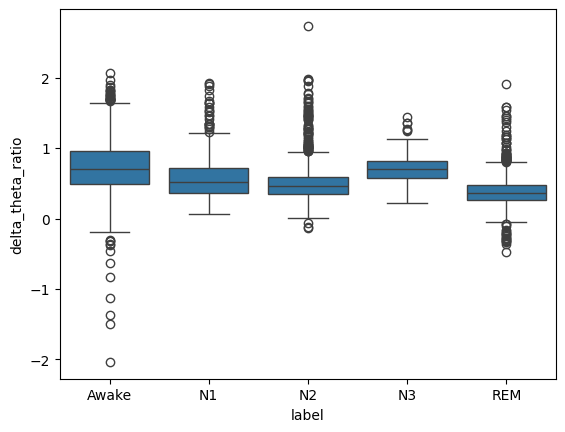

In [30]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='delta_theta_ratio')

<Axes: xlabel='label', ylabel='delta_alpha_ratio'>

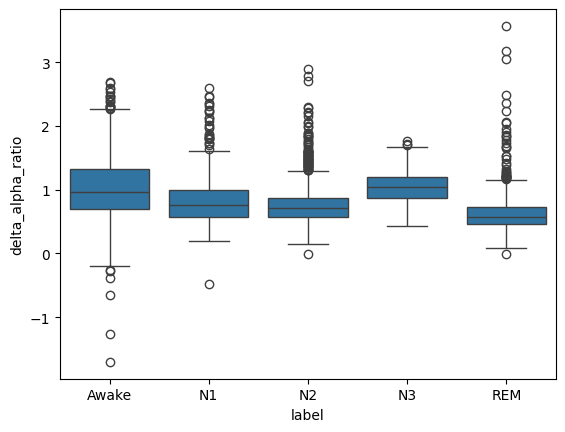

In [31]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='delta_alpha_ratio')

<Axes: xlabel='label', ylabel='hjorth_activity'>

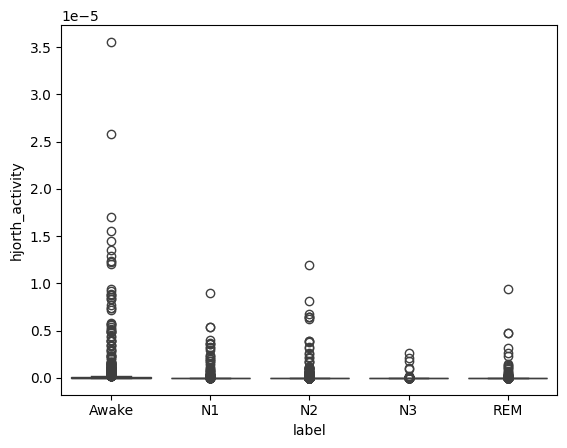

In [32]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='hjorth_activity')

<Axes: xlabel='label', ylabel='hjorth_mobility'>

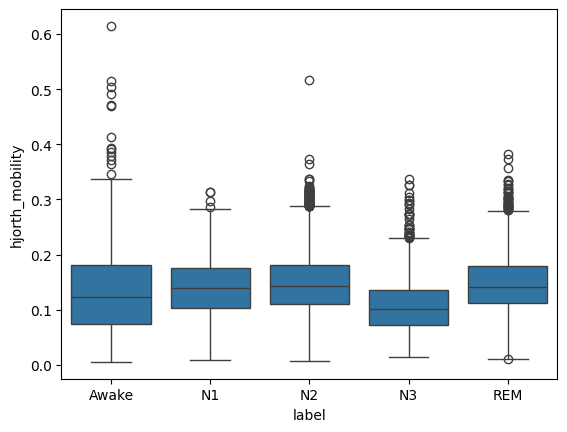

In [33]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='hjorth_mobility')

<Axes: xlabel='label', ylabel='hjorth_complexity'>

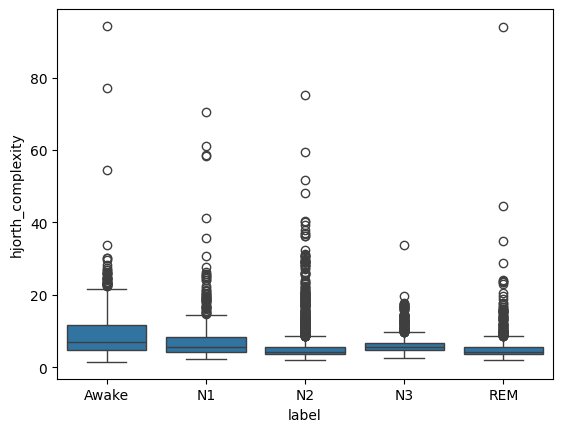

In [35]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='hjorth_complexity')

<Axes: xlabel='label', ylabel='spectral_entropy'>

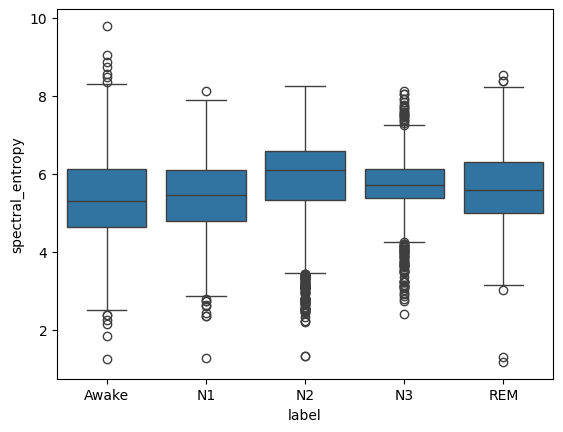

In [36]:
import seaborn as sns

sns.boxplot(feature_df, x='label', y='spectral_entropy')